In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from getdist import MCSamples, plots

In [8]:
# Load the data (updated for the warning)
df = pd.read_csv("./output/mf_w_lowz2.txt", sep=r"\s+", comment="#", header=None)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
# df.columns = ["omega_m", "sigma8", "prior", "posterior"]
df.columns = ["w", "prior", "posterior"]

(3200, 3)


In [9]:
# --- Step 1: Prepare samples array ---
samples = df[["w"]].values

# --- Step 2: Parameter names and LaTeX labels ---
names = ['w']
labels = [r'w']

weights = np.exp(df["posterior"] - df["posterior"].max())
weights /= weights.sum()  # Normalize weights

# --- Step 3: Create MCSamples object ---
mc = MCSamples(samples=samples, names=names, labels=labels)

# Print the fitted value with 68% credible interval
#    mean ± 1σ:
print("mean ± σ:", mc.mean('w'), "±", mc.std('w'))

print("inline:", mc.getInlineLatex('w'))   # e.g. w = -1.0003 \pm 0.0009


Removed no burn in
mean ± σ: -0.9999681232070141 ± 0.001540046173715571
inline: w = -0.99997\pm 0.0015


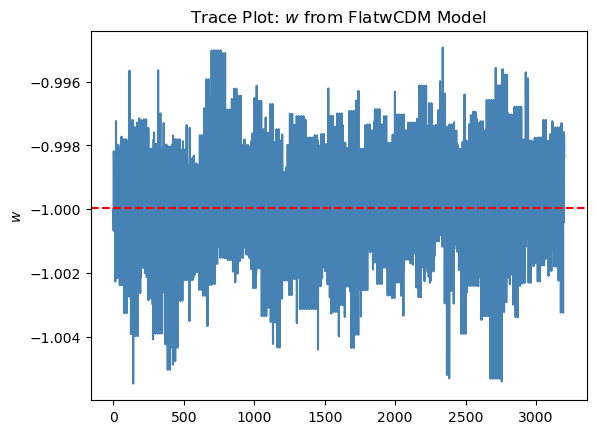

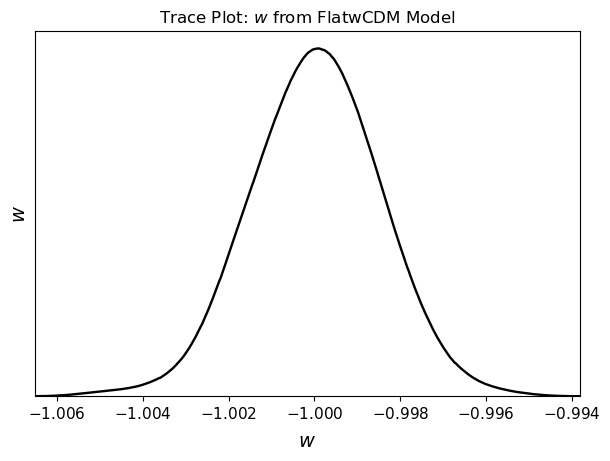

In [10]:
# Trace plot for omega_m
plt.plot(df["w"], color='steelblue')
w_mean = np.mean(df["w"])
plt.axhline(w_mean, color="red", linestyle="--", label=f"mean = {w_mean:.5f}")
plt.ylabel(r'$w$')
plt.title("Trace Plot: $w$ from FlatwCDM Model")

plt.show()

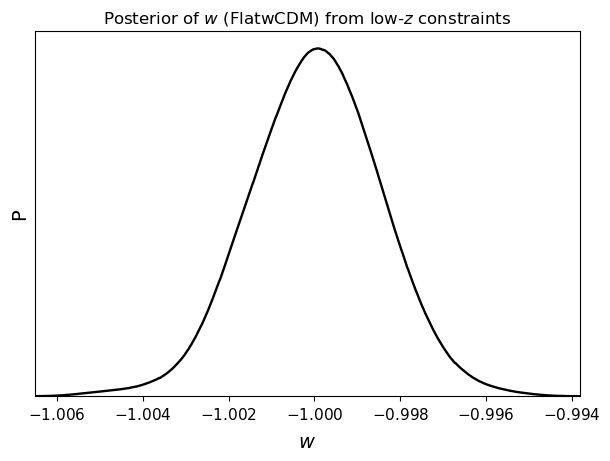

In [11]:
# posterior plot
g = plots.getSinglePlotter()
g.plot_1d(mc, "w", normalized=True)
plt.title(r"Posterior of $w$ (FlatwCDM) from low-$z$ constraints")
plt.show()

In [17]:
# Load the data (updated for the warning)
df1 = pd.read_csv("./output/mf_noise_base.txt", sep=r"\s+", comment="#", header=None)
df2 = pd.read_csv("./output/mf_noise_date_v2.txt", sep=r"\s+", comment="#", header=None)
df3 = pd.read_csv("./output/mf_noise_v1.txt", sep=r"\s+", comment="#", header=None)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
df1.columns = ["omega_m", "sigma8", "prior", "posterior"]
df2.columns = ["omega_m", "sigma8", "prior", "posterior"]
df3.columns = ["omega_m", "sigma8", "prior", "posterior"]

(3200, 3)


In [18]:
# --- Apply burn-in: drop first 30% of each chain ---
burn_frac = 0.3

def burn_df(df, frac):
    n = len(df)
    n_burn = int(frac * n)
    return df.iloc[n_burn:].reset_index(drop=True)

df1 = burn_df(df1, burn_frac)
df2 = burn_df(df2, burn_frac)
df3 = burn_df(df3, burn_frac)

# (Optional) check shapes
print(df1.shape, df2.shape, df3.shape)

(44800, 4) (44800, 4) (44800, 4)


Removed no burn in


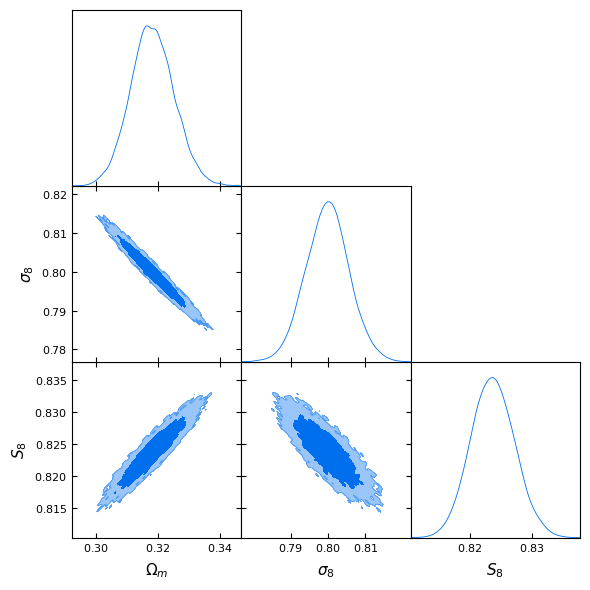

In [19]:
from getdist import MCSamples, plots

# --- Step 1: Compute S8 ---
df1["S8"] = df1["sigma8"] * (df1["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df1[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

Removed no burn in


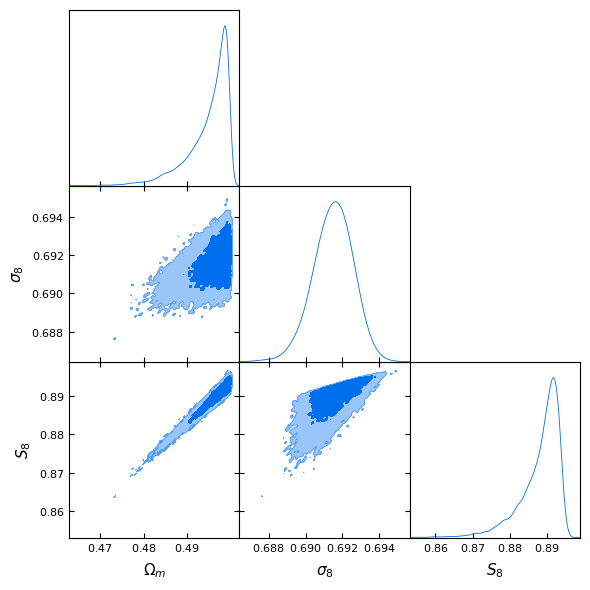

In [20]:
from getdist import MCSamples, plots

# --- Step 1: Compute S8 ---
df2["S8"] = df2["sigma8"] * (df2["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df2[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

Removed no burn in


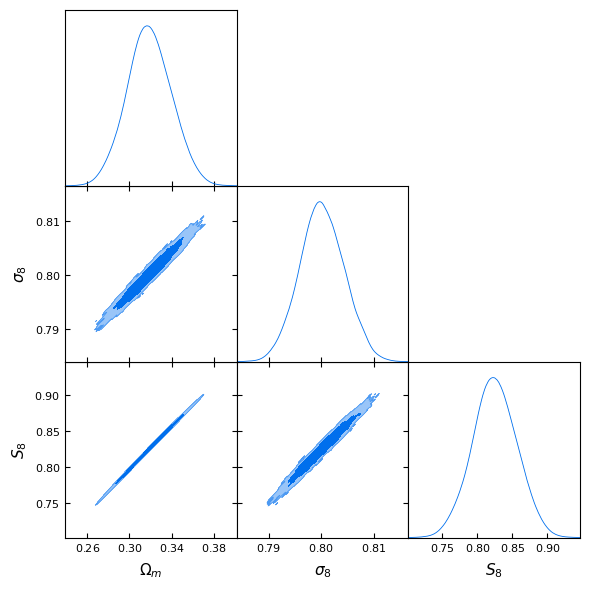

In [21]:
from getdist import MCSamples, plots

# --- Step 1: Compute S8 ---
df3["S8"] = df3["sigma8"] * (df3["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df3[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()